## 2. Загрузить https://www.kaggle.com/datasets/sanikamal/horses-or-humans-dataset


In [56]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sanikamal/horses-or-humans-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Igor\.cache\kagglehub\datasets\sanikamal\horses-or-humans-dataset\versions\1


In [57]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.metrics import AUC

train_dir = r"C:\Users\Igor\.cache\kagglehub\datasets\sanikamal\horses-or-humans-dataset\versions\1\horse-or-human\train"
val_dir = r"C:\Users\Igor\.cache\kagglehub\datasets\sanikamal\horses-or-humans-dataset\versions\1\horse-or-human\validation"

## 3. Выполнить аугментацию изображений.


In [58]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)
val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 1027 images belonging to 2 classes.
Found 256 images belonging to 2 classes.


## 1. Построить CNN для бинарной классификации изображений.


In [59]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy', AUC(name='auc')])

## 4. Обучить модель на обученном датасете.

In [60]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 436ms/step - accuracy: 0.5844 - auc: 0.5966 - loss: 0.9175 - val_accuracy: 0.5430 - val_auc: 0.8182 - val_loss: 0.7748
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 409ms/step - accuracy: 0.7908 - auc: 0.8480 - loss: 0.4844 - val_accuracy: 0.5742 - val_auc: 0.8083 - val_loss: 1.9890
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 418ms/step - accuracy: 0.8074 - auc: 0.8993 - loss: 0.4059 - val_accuracy: 0.5547 - val_auc: 0.7227 - val_loss: 2.9172
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 409ms/step - accuracy: 0.8900 - auc: 0.9612 - loss: 0.2530 - val_accuracy: 0.6094 - val_auc: 0.8047 - val_loss: 2.2911
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 410ms/step - accuracy: 0.8889 - auc: 0.9606 - loss: 0.2578 - val_accuracy: 0.5195 - val_auc: 0.6250 - val_loss: 3.8422
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 408ms/step - accuracy: 0.9349 - auc: 0.9820 - loss: 0.1748 - val_accuracy: 0.5664 - val_auc: 0.7656 - val_loss: 2.4837
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━

## 5. Получить метрику ROC-AUC.


In [61]:
best_val_auc = max(history.history['val_auc'])
print(f"Лучшее значение ROC-AUC на валидации: {best_val_auc:.3f}")

Лучшее значение ROC-AUC на валидации: 0.818


## 6. Добиться значения ROC-AUC > 0.6.


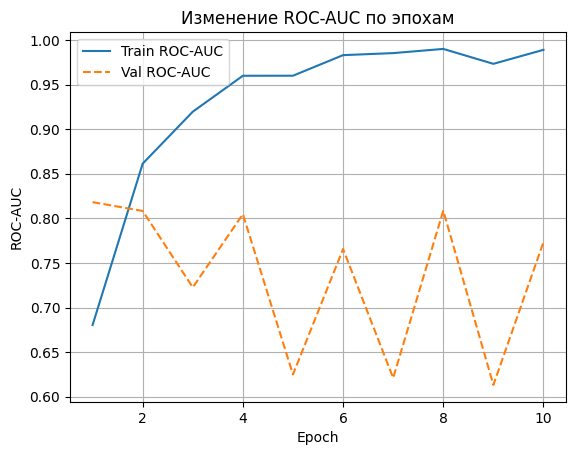

In [62]:
import matplotlib.pyplot as plt
auc_history = history.history['auc']
val_auc_history = history.history['val_auc']

epochs = range(1, len(auc_history) + 1)
plt.plot(epochs, auc_history, label='Train ROC-AUC')
plt.plot(epochs, val_auc_history, label='Val ROC-AUC', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.title('Изменение ROC-AUC по эпохам')
plt.legend()
plt.grid(True)
plt.show()


## * Дополнительное задание: 
Сделать интерфейс, в который можно загружать изображение и получать информацию о том, человек находится на фото или лошадь

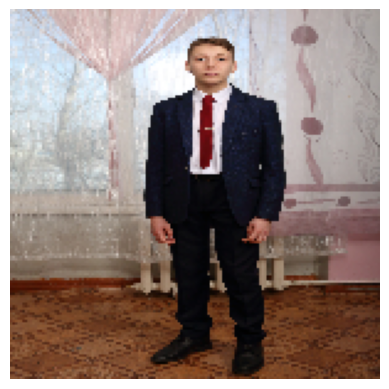

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Prediction: Human (probability: 1.00)


In [63]:
from matplotlib import pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"D:\Фото и видео\Camera\9 класс\HE7B0500.JPG"
# Заменить your_image.jpg на реальное имя файла
img = image.load_img(img_path, target_size=(150,150))
plt.imshow(img)
plt.axis('off')
plt.show()
x = image.img_to_array(img)
x = x / 255.0
x = np.expand_dims(x, axis=0)

prob = float(model.predict(x)[0][0])
label = 'Human' if prob > 0.5 else 'Horse'
print(f'Prediction: {label} (probability: {prob:.2f})')

In [ ]:
import sys
from PyQt5 import QtWidgets
from PyQt5.QtWidgets import QFileDialog, QLabel, QPushButton, QLineEdit, QVBoxLayout, QWidget
from PyQt5.QtGui import QPixmap
import numpy as np

class HorseHumanApp(QWidget):
    def __init__(self):
        super().__init__()
        self.setWindowTitle('Horse or Human Classifier')
        self.resize(400, 400)
        layout = QVBoxLayout()

        self.img_label = QLabel('Предварительный просмотр фото')
        self.img_label.setFixedSize(200, 200)
        self.img_label.setScaledContents(True)
        layout.addWidget(self.img_label)

        self.textbox = QLineEdit(self)
        self.textbox.setPlaceholderText('Путь к изображению...')
        layout.addWidget(self.textbox)

        self.browse_btn = QPushButton('Выбрать файл')
        self.browse_btn.clicked.connect(self.browse_file)
        layout.addWidget(self.browse_btn)

        self.predict_btn = QPushButton('Определить')
        self.predict_btn.clicked.connect(self.predict_image)
        layout.addWidget(self.predict_btn)

        self.result_label = QLabel('Результат будет здесь...')
        layout.addWidget(self.result_label)

        self.setLayout(layout)

    def browse_file(self):
        fname, _ = QFileDialog.getOpenFileName(self, 'Выбрать изображение', '', 'Image files (*.jpg *.jpeg *.png)')
        if fname:
            self.textbox.setText(fname)
            pixmap = QPixmap(fname)
            self.img_label.setPixmap(pixmap)

    def predict_image(self):
        img_path = self.textbox.text()
        try:
            img = image.load_img(img_path, target_size=(150,150))
            x = image.img_to_array(img)/255.0
            x = np.expand_dims(x, axis=0)
            prob = float(model.predict(x)[0][0])
            label = 'Человек' if prob > 0.5 else 'Лошадь'
            self.result_label.setText(f'Результат: {label} (вероятность: {prob:.2f})')
        except Exception as e:
            self.result_label.setText(f'Ошибка: {str(e)}')

if __name__ == '__main__':
    app = QtWidgets.QApplication(sys.argv)
    window = HorseHumanApp()
    window.show()
    sys.exit(app.exec_())
